In [1]:
# Evaluation (Target: UNSW-NB15)
# Loads models trained on NSL-KDD and evaluates them on UNSW-NB15 (cross-dataset generalization).

In [2]:
# --- Cell 1: Setup & Load Artifacts ---
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib

from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.data import Data
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# GNNModel must match Notebook 1 exactly
class GNNModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super(GNNModel, self).__init__()
        if model_type == 'GCN':
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.conv1 = GATConv(input_dim, hidden_dim, heads=8, concat=True)
            self.conv2 = GATConv(hidden_dim * 8, output_dim, heads=1, concat=False)
        elif model_type == 'SAGE':
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out   = model(data)
    preds  = out.argmax(dim=1)  # Test on ALL nodes (cross-dataset eval, no mask)
    y_true = data.y
    return {
        'accuracy':  accuracy_score(y_true.cpu(), preds.cpu()),
        'f1':        f1_score(y_true.cpu(), preds.cpu(), zero_division=0),
        'precision': precision_score(y_true.cpu(), preds.cpu(), zero_division=0),
        'recall':    recall_score(y_true.cpu(), preds.cpu(), zero_division=0)
    }

# Load the scaler saved by Notebook 1
scaler = joblib.load('ids_scaler.pkl')
print('Scaler loaded.')

Scaler loaded.


In [3]:
# --- Cell 2: Load & Preprocess UNSW-NB15 ---
df_unsw = pd.read_csv('UNSW_NB15_testing-set.csv')

# Map UNSW column names to the common feature names used in training
rename_dict = {
    'dur':        'duration',
    'sbytes':     'src_bytes',
    'dbytes':     'dst_bytes',
    'ct_srv_src': 'count',
    'ct_srv_dst': 'srv_count'
}
df_unsw = df_unsw.rename(columns=rename_dict)

COMMON_FEATURES = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']

missing = [f for f in COMMON_FEATURES if f not in df_unsw.columns]
if missing:
    print(f'ERROR: Columns still missing after rename: {missing}')
    print('Available columns:', df_unsw.columns.tolist())
else:
    print('All features aligned.')

X_unsw = df_unsw[COMMON_FEATURES].fillna(0)
X_unsw_scaled = scaler.transform(X_unsw)  # Use NSL-KDD scaler for consistent scaling

# UNSW-NB15 label column is 'label' (0=normal, 1=attack)
y_unsw = df_unsw['label'].values
print(f'Rows: {len(df_unsw)} | Label distribution: {pd.Series(y_unsw).value_counts().to_dict()}')

All features aligned.
Rows: 175341 | Label distribution: {1: 119341, 0: 56000}


In [4]:
# --- Cell 3: Graph Construction ---
# We use sequential edges (row i -> row i+1) to keep num_nodes == len(df_unsw),
# which must equal the feature matrix size.  This mirrors the approach in Notebook 1.
# NOTE: The original code created edge nodes from 'proto'/'service' strings, which
# produced a different num_nodes than the feature matrix, causing an index error.

num_nodes = len(df_unsw)
src_nodes  = np.arange(0, num_nodes - 1)
dst_nodes  = np.arange(1, num_nodes)
edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

unsw_graph_data = Data(
    x=torch.tensor(X_unsw_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y_unsw, dtype=torch.long)
)

print(f'Graph: {unsw_graph_data.num_nodes} nodes, {unsw_graph_data.num_edges} edges')
assert unsw_graph_data.num_nodes == len(df_unsw), 'Node count mismatch!'

Graph: 175341 nodes, 175340 edges


C:\Users\ceb1003\AppData\Local\Temp\ipykernel_21212\4075066755.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)


In [5]:
# --- Cell 4: Evaluate All Models on UNSW-NB15 ---
model_types = ['GCN', 'GAT', 'SAGE']
comparison_results_unsw = {}

for m_type in model_types:
    print(f'Testing {m_type} on UNSW-NB15...')
    model = GNNModel(input_dim=len(COMMON_FEATURES), hidden_dim=64, output_dim=2, model_type=m_type)
    try:
        model.load_state_dict(torch.load(f'gnn_model_{m_type.lower()}.pt'))
        model.eval()
        comparison_results_unsw[m_type] = evaluate(model, unsw_graph_data)
        print(f'  Done.')
    except FileNotFoundError:
        print(f'  Warning: gnn_model_{m_type.lower()}.pt not found. Skipping.')

Testing GCN on UNSW-NB15...
  Done.
Testing GAT on UNSW-NB15...
  Done.
Testing SAGE on UNSW-NB15...
  Done.


In [6]:
# --- Cell 5: Print Results ---
print('UNSW-NB15 Cross-Dataset Results (Trained on NSL-KDD):')
for m_type, metrics in comparison_results_unsw.items():
    print(f'\n{m_type}:')
    for metric, value in metrics.items():
        print(f'  {metric.capitalize()}: {value:.4f}')

UNSW-NB15 Cross-Dataset Results (Trained on NSL-KDD):

GCN:
  Accuracy: 0.3198
  F1: 0.0017
  Precision: 0.7615
  Recall: 0.0008

GAT:
  Accuracy: 0.3198
  F1: 0.0020
  Precision: 0.7532
  Recall: 0.0010

SAGE:
  Accuracy: 0.3190
  F1: 0.0032
  Precision: 0.4232
  Recall: 0.0016


      accuracy        f1  precision    recall
GCN   0.319765  0.001657   0.761538  0.000830
GAT   0.319834  0.001992   0.753165  0.000997
SAGE  0.318978  0.003222   0.423246  0.001617


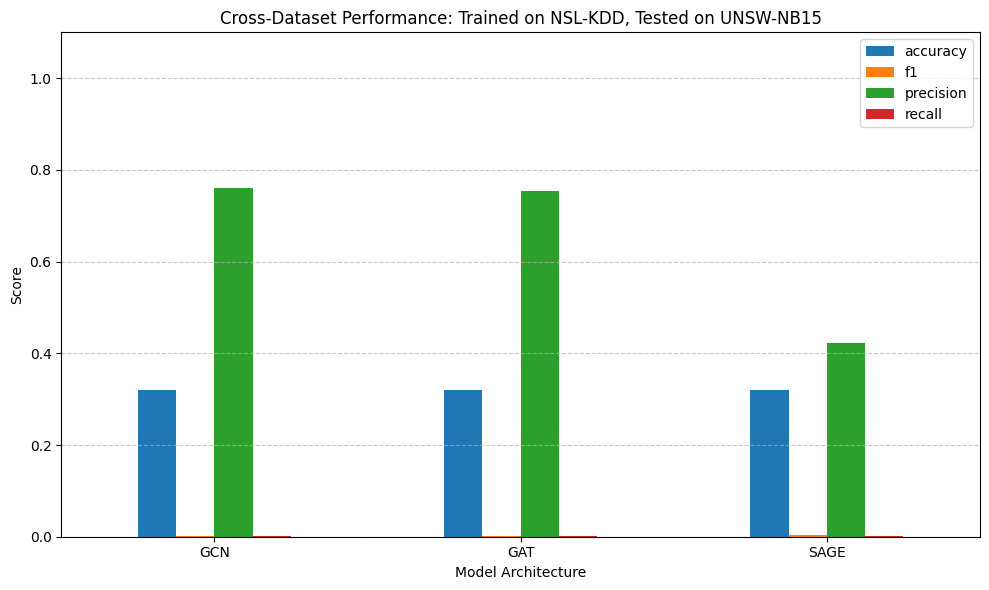

In [7]:
# --- Cell 6: Plot ---
if comparison_results_unsw:
    df_compare_unsw = pd.DataFrame(comparison_results_unsw).T
    print(df_compare_unsw)
    fig, ax = plt.subplots(figsize=(10, 6))
    df_compare_unsw.plot(kind='bar', ax=ax)
    ax.set_title('Cross-Dataset Performance: Trained on NSL-KDD, Tested on UNSW-NB15')
    ax.set_ylabel('Score')
    ax.set_xlabel('Model Architecture')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('No results to plot.')